# 06 Diffusion Models：扩散模型（DDPM）——加噪与去噪

> 前置：`probability/07-sampling-monte-carlo`、`05-vae`（生成模型范式）。
> 目标：理解 DDPM 的**前向加噪过程**与**反向去噪过程**的完整数学，实现一个微型扩散模型，观察"噪声 → 清晰图像"的生成动画。

## 直觉

把"生成"反过来想：与其从零画一张图，不如**从纯噪声一步步去掉噪声**。类比：往照片上一点点加噪直到面目全非（前向），再学习如何一步步还原（反向）。

## 前向过程（加噪，闭式可算）

对每个时间步 $t$ 加一点高斯噪声。妙处在于：**任意时刻 $t$ 的图像可以直接从 $x_0$ 闭式计算**，不用逐步推：

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar\alpha_t}\, x_0,\; (1-\bar\alpha_t) I)$$

其中 $\alpha_t = 1 - \beta_t$（$\beta_t$ 是噪声调度），$\bar\alpha_t = \prod_{s=1}^t \alpha_s$。等价采样：

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

## 反向过程（去噪，训练目标）

反向 $q(x_{t-1}|x_t)$ 不可解，但可以证明当 $\beta_t$ 很小时它近似高斯，于是用神经网络 $\mu_\theta(x_t, t)$ 去拟合。DDPM 的洞见：**预测噪声比预测均值更简单**——训练目标退化为：

$$\mathcal{L} = \mathbb{E}_{x_0, t, \varepsilon}\left[\| \varepsilon_\theta(x_t, t) - \varepsilon \|^2\right]$$

（预测 $\varepsilon$ 等价于预测 $\mu$，因为 $\mu$ 与 $\varepsilon$ 只差一个可计算系数。）

## 采样（反向迭代）

从 $x_T \sim \mathcal{N}(0, I)$ 出发，逐步：

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\, \varepsilon_\theta(x_t, t)\right) + \sigma_t z$$

其中最后一步 $z=0$（$t=1$ 不加新噪声）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
def make_bars_ddpm(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 8, 8))
    for i in range(n):
        kind = rng.integers(0, 4)
        if kind == 0: X[i, 0, :] = 1.0
        elif kind == 1: X[i, -1, :] = 1.0
        elif kind == 2: X[i, :, 0] = 1.0
        else: X[i, :, -1] = 1.0
    return (X * 2 - 1).reshape(n, -1)     # 二值 → [-1, 1]，与高斯噪声同量纲

Xdd = make_bars_ddpm()
print("数据:", Xdd.shape, "取值范围 [%.1f, %.1f]" % (Xdd.min(), Xdd.max()))

T = 200
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, 0)
sqrt_ab = torch.sqrt(alpha_bar)
sqrt_1mab = torch.sqrt(1 - alpha_bar)

def q_sample(x0, t, noise):
    return sqrt_ab[t].unsqueeze(1) * x0 + sqrt_1mab[t].unsqueeze(1) * noise

print("ᾱ_0 = %.4f → 最后一步 ᾱ_T = %.4f（几乎全是噪声）" % (alpha_bar[0].item(), alpha_bar[-1].item()))

数据: (2000, 64) 取值范围 [-1.0, 1.0]
ᾱ_0 = 0.9999 → 最后一步 ᾱ_T = 0.1322（几乎全是噪声）


## 前向加噪可视化

同一张图像，在 $t=0, 40, 100, 199$ 时刻的样子——加噪调度保证 $x_T$ 近似标准高斯。

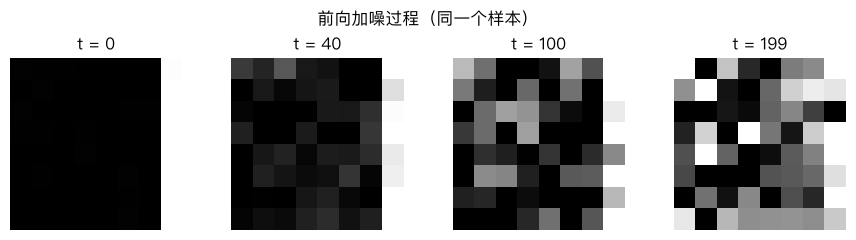

In [3]:
x0 = torch.tensor(Xdd[:1], dtype=torch.float32)
fig, axes = plt.subplots(1, 4, figsize=(9, 2.4))
for ax, t in zip(axes, [0, 40, 100, 199]):
    xt = q_sample(x0, torch.tensor([t]), torch.randn_like(x0))
    ax.imshow(xt[0].numpy().reshape(8, 8), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"t = {t}")
    ax.axis("off")
plt.suptitle("前向加噪过程（同一个样本）")
plt.tight_layout(); plt.show()

## 去噪网络

输入：带噪图像 $x_t$ + 时间 $t$（用正弦位置编码嵌入）。输出：预测的噪声 $\varepsilon$。这里用 MLP（真实扩散模型用 U-Net/DiT，见 07 课）。

In [4]:
def time_embedding(t, dim=16):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, dtype=torch.float32) / half)
    arg = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.sin(arg), torch.cos(arg)], dim=-1)

class TimeMLP(nn.Module):
    def __init__(self, dim=64, t_dim=16, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim + t_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, dim))
    def forward(self, x, t):
        return self.net(torch.cat([x, time_embedding(t)], dim=-1))

model = TimeMLP()
print("去噪网络参数量:", sum(p.numel() for p in model.parameters()))

去噪网络参数量: 35136


In [5]:
Xd_t = torch.tensor(Xdd, dtype=torch.float32)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
n = len(Xd_t)
for step in range(1500):
    idx = torch.randint(0, n, (128,))
    x0 = Xd_t[idx]
    t = torch.randint(0, T, (128,))
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    opt.zero_grad()
    loss = F.mse_loss(model(xt, t), noise)      # 预测噪声
    loss.backward(); opt.step()
    if step % 300 == 0:
        print(f"step {step:4d}  loss = {loss.item():.4f}")

step    0  loss = 1.0343
step  300  loss = 0.2749
step  600  loss = 0.2243


step  900  loss = 0.1980
step 1200  loss = 0.1817


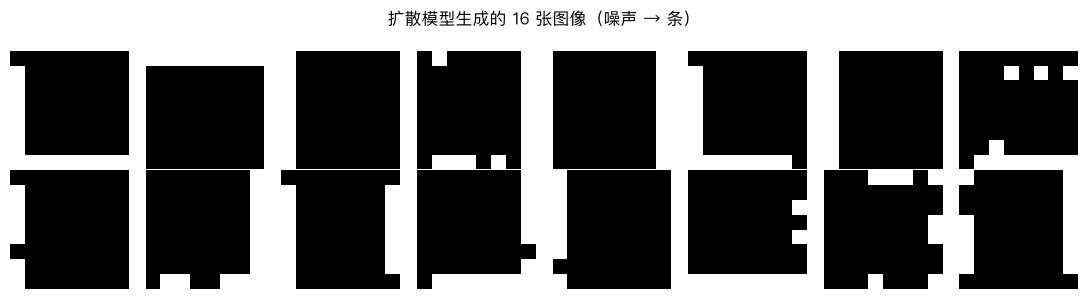

In [6]:
@torch.no_grad()
def sample(n=16):
    x = torch.randn(n, 64)
    for t in reversed(range(T)):
        eps = model(x, torch.full((n,), t, dtype=torch.long))
        x = (x - (1 - alphas[t]) / torch.sqrt(1 - alpha_bar[t]) * eps) / torch.sqrt(alphas[t])
        if t > 0:
            x = x + torch.sqrt(betas[t]) * torch.randn_like(x)
    return x

gen = sample(16)
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for i in range(16):
    axes[i // 8, i % 8].imshow((gen[i] > 0).numpy().reshape(8, 8), cmap="gray")
    axes[i // 8, i % 8].axis("off")
plt.suptitle("扩散模型生成的 16 张图像（噪声 → 条）")
plt.tight_layout(); plt.show()

## 采样过程可视化：去噪动画

从纯噪声出发，观察第 199→149→99→49→0 步的中间状态——**模型逐步"雕刻"出结构**。

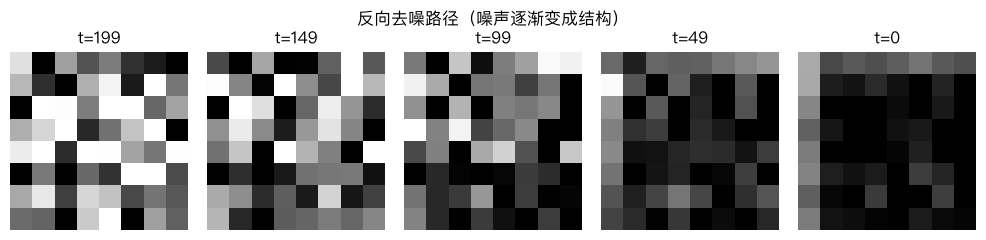

In [7]:
@torch.no_grad()
def sample_path(t_steps=(199, 149, 99, 49, 0)):
    x = torch.randn(1, 64)
    states = []
    for t in reversed(range(T)):
        eps = model(x, torch.full((1,), t, dtype=torch.long))
        x = (x - (1 - alphas[t]) / torch.sqrt(1 - alpha_bar[t]) * eps) / torch.sqrt(alphas[t])
        if t > 0:
            x = x + torch.sqrt(betas[t]) * torch.randn_like(x)
        if t in t_steps:
            states.append((t, x.clone()))
    return states

states = sample_path()
fig, axes = plt.subplots(1, len(states), figsize=(10, 2.4))
for ax, (t, x) in zip(axes, states):
    ax.imshow(x[0].numpy().reshape(8, 8), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"t={t}"); ax.axis("off")
plt.suptitle("反向去噪路径（噪声逐渐变成结构）")
plt.tight_layout(); plt.show()

## 总结与延伸

1. **DDPM 三件套**：线性噪声调度 β_t → 闭式加噪 x_t = √ᾱ·x₀ + √(1−ᾱ)·ε → 训练网络预测 ε → 按采样公式逐步去噪。
2. **为什么稳定**：训练目标是**显式的回归（MSE on noise）**，不像 GAN 是对抗博弈——没有模式坍缩，没有纳什均衡。
3. **代价**：生成要跑 T=1000 步。改进：DDIM（确定性加速）、蒸馏（few-step）、流匹配/一致性模型。
4. **真实实现**：Stable Diffusion 用 U-Net（含交叉注意力）在 VAE 潜空间跑扩散，文本条件引导——下一课拆解。

## 课后练习

1. 把 T 从 200 减到 50，重新训练，比较生成质量——体会"噪声调度粒度"的作用。
2. 把线性调度换成余弦调度 `β_t = cos 曲线`，观察训练 loss 曲线变化。
3. 采样时把最后 10 步的 `σ_t z` 全去掉（确定性采样），看生成质量是否下降。